In [3]:
import os
import shutil
import random
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models
from sklearn.utils import class_weight


In [4]:
train_dir = "dataset/train"
val_dir = "dataset/val"

img_size = 224
batch_size = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='binary'
)

val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='binary'
)


Found 1484 images belonging to 2 classes.
Found 372 images belonging to 2 classes.


In [5]:
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)

class_weights = dict(enumerate(class_weights))
print("Class Weights:", class_weights)


Class Weights: {0: 0.902676399026764, 1: 1.1208459214501512}


In [6]:
base_model = MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False


In [7]:
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])


In [8]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224 (Functional)    │ (None, 7, 7, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         163,968 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [9]:
history = model.fit(
    train_generator,
    epochs=10,
    validation_data=val_generator,
    class_weight=class_weights
)


C:\Anaconda3\envs\aimj\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 276s 6s/step - accuracy: 0.7931 - loss: 0.4422 - val_accuracy: 0.8710 - val_loss: 0.2764
Epoch 2/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 293s 5s/step - accuracy: 0.8740 - loss: 0.2848 - val_accuracy: 0.8656 - val_loss: 0.3102
Epoch 3/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 295s 6s/step - accuracy: 0.9016 - loss: 0.2331 - val_accuracy: 0.8790 - val_loss: 0.2500
Epoch 4/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 301s 6s/step - accuracy: 0.8996 - loss: 0.2265 - val_accuracy: 0.8790 - val_loss: 0.2569
Epoch 5/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 295s 6s/step - accuracy: 0.9178 - loss: 0.1930 - val_accuracy: 0.8871 - val_loss: 0.2260
Epoch 6/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 398s 7s/step - accuracy: 0.9346 - loss: 0.1595 - val_accuracy: 0.9113 - val_loss: 0.1954
Epoch 7/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 251s 5s/step - accuracy: 0.9394 - loss: 0.1607 - val_accuracy: 0.9140 - val_loss: 0.1933
Epoch 8/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 218s 5s/step - accuracy: 0.9447 - loss: 0.1498 - val_accuracy: 0.8683 - v

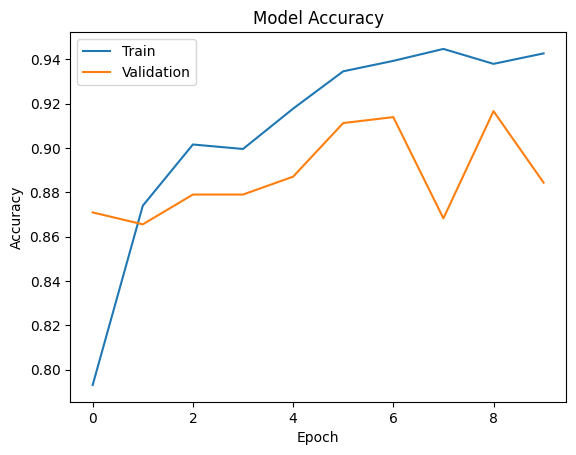

In [10]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train", "Validation"])
plt.show()


In [11]:
model.save("tire_defect_model.h5")
print("Model saved successfully ✅")


Model saved successfully ✅


In [12]:
from tensorflow.keras.preprocessing import image

img_path = "test.jpg"  # change file name

img = image.load_img(img_path, target_size=(224,224))
img_array = image.img_to_array(img)/255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)

if prediction[0][0] > 0.5:
    print("Prediction: Defective Tire")
else:
    print("Prediction: Good Tire")


1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
Prediction: Good Tire


In [13]:
print(train_generator.class_indices)

{'defective': 0, 'good': 1}
